-----------
Initializing structure...
Halving computational cell along direction y
time for choose_chunkdivision = 0.000553846 s
Working in 2D dimensions.
Computational cell is 8.5 x 10 x 0 with resolution 60
time for set_epsilon = 0.0573859 s
-----------
field decay(t = 50.00833333333333): 0.11392641853211968 / 0.11392641853211968 = 1.0
field decay(t = 100.01666666666667): 1.0115785017733523e-15 / 0.11392641853211968 = 8.879226739565716e-15
run 0 finished at t = 100.01666666666667 (12002 timesteps)
-----------
Initializing structure...
Halving computational cell along direction y
time for choose_chunkdivision = 0.000258923 s
Working in 2D dimensions.
Computational cell is 8.5 x 10 x 0 with resolution 60
     block, center = (-2.25,0,0)
          size (4,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0,0,0)
          size (0.5,5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielec

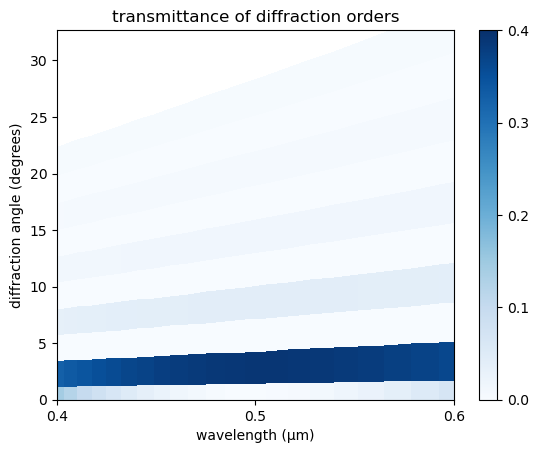

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np

import meep as mp

resolution = 60  # pixels/μm

dpml = 1.0  # PML thickness
dsub = 3.0  # substrate thickness
dpad = 3.0  # padding between grating and PML
gp = 10.0  # grating period
gh = 0.5  # grating height
gdc = 0.5  # grating duty cycle

sx = dpml + dsub + gh + dpad + dpml
sy = gp

cell_size = mp.Vector3(sx, sy, 0)
pml_layers = [mp.PML(thickness=dpml, direction=mp.X)]

wvl_min = 0.4  # min wavelength
wvl_max = 0.6  # max wavelength
fmin = 1 / wvl_max  # min frequency
fmax = 1 / wvl_min  # max frequency
fcen = 0.5 * (fmin + fmax)  # center frequency
df = fmax - fmin  # frequency width

src_pt = mp.Vector3(-0.5 * sx + dpml + 0.5 * dsub, 0, 0)
sources = [
    mp.Source(
        mp.GaussianSource(fcen, fwidth=df),
        component=mp.Ez,
        center=src_pt,
        size=mp.Vector3(0, sy, 0),
    )
]

k_point = mp.Vector3(0, 0, 0)

glass = mp.Medium(index=1.5)

symmetries = [mp.Mirror(mp.Y)]

sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    k_point=k_point,
    default_material=glass,
    sources=sources,
    symmetries=symmetries,
)

nfreq = 21
mon_pt = mp.Vector3(0.5 * sx - dpml - 0.5 * dpad, 0, 0)
flux_mon = sim.add_flux(
    fcen, df, nfreq, mp.FluxRegion(center=mon_pt, size=mp.Vector3(0, sy, 0))
)

sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, mon_pt, 1e-9))

input_flux = mp.get_fluxes(flux_mon)

sim.reset_meep()

geometry = [
    mp.Block(
        material=glass,
        size=mp.Vector3(dpml + dsub, mp.inf, mp.inf),
        center=mp.Vector3(-0.5 * sx + 0.5 * (dpml + dsub), 0, 0),
    ),
    mp.Block(
        material=glass,
        size=mp.Vector3(gh, gdc * gp, mp.inf),
        center=mp.Vector3(-0.5 * sx + dpml + dsub + 0.5 * gh, 0, 0),
    ),
]

sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    k_point=k_point,
    sources=sources,
    symmetries=symmetries,
)

mode_mon = sim.add_flux(
    fcen, df, nfreq, mp.FluxRegion(center=mon_pt, size=mp.Vector3(0, sy, 0))
)

sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, mon_pt, 1e-9))

freqs = mp.get_eigenmode_freqs(mode_mon)

nmode = 10
res = sim.get_eigenmode_coefficients(
    mode_mon, range(1, nmode + 1), eig_parity=mp.ODD_Z + mp.EVEN_Y
)
coeffs = res.alpha
kdom = res.kdom

mode_wvl = []
mode_angle = []
mode_tran = []

for nm in range(nmode):
    for nf in range(nfreq):
        mode_wvl.append(1 / freqs[nf])
        mode_angle.append(math.degrees(math.acos(kdom[nm * nfreq + nf].x / freqs[nf])))
        tran = abs(coeffs[nm, nf, 0]) ** 2 / input_flux[nf]
        mode_tran.append(0.5 * tran if nm != 0 else tran)
        print(
            "grating{}:, {:.5f}, {:.2f}, {:.8f}".format(
                nm, mode_wvl[-1], mode_angle[-1], mode_tran[-1]
            )
        )

tran_max = round(max(mode_tran), 1)

plt.figure()
plt.pcolormesh(
    np.reshape(mode_wvl, (nmode, nfreq)),
    np.reshape(mode_angle, (nmode, nfreq)),
    np.reshape(mode_tran, (nmode, nfreq)),
    cmap="Blues",
    shading="nearest",
    vmin=0,
    vmax=tran_max,
)
plt.axis([min(mode_wvl), max(mode_wvl), min(mode_angle), max(mode_angle)])
plt.xlabel("wavelength (μm)")
plt.ylabel("diffraction angle (degrees)")
plt.xticks(list(np.arange(0.4, 0.7, 0.1)))
plt.yticks(list(range(0, 35, 5)))
plt.title("transmittance of diffraction orders")
cbar = plt.colorbar()
cbar.set_ticks(list(np.arange(0, tran_max + 0.1, 0.1)))
cbar.set_ticklabels([f"{t:.1f}" for t in np.arange(0, tran_max + 0.1, 0.1)])
plt.show()